In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    ConfusionMatrixDisplay,
    make_scorer,
    confusion_matrix
)

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# uncomment and run the following line if using Google Colab
# from google.colab import drive
# Write your code here to read the data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# loading data into a pandas dataframe
backpaindf = pd.read_csv("/content/drive/My Drive/backpain.csv")

In [6]:
backpaindf.head()

,pelvic_incidence,pelvic tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,pelvic_slope,Direct_tilt,thoracic_slope,cervical_tilt,sacrum_angle,scoliosis_slope,Status
0,63.02782,22.55259,39.60912,40.47523,98.67292,-0.25440,0.74450,12.56610,14.53860,15.30468,-28.65850,43.51230,Abnormal
1,39.05695,10.06099,25.01538,28.99596,114.40543,4.56426,0.41519,12.88740,17.53230,16.78486,-25.53061,16.11020,Abnormal
2,68.83202,22.21848,50.09219,46.61354,105.98514,-3.53032,0.47489,26.83430,17.48610,16.65897,-29.03189,19.22210,Abnormal
3,69.29701,24.65288,44.31124,44.64413,101.86850,11.21152,0.36935,23.56030,12.70740,11.42447,-30.47025,18.83290,Abnormal
4,49.71286,9.65207,28.31741,40.06078,108.16872,7.91850,0.54336,35.49400,15.95460,8.87237,-16.37838,24.91710,Abnormal


In [7]:
backpaindf.tail()

,pelvic_incidence,pelvic tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,pelvic_slope,Direct_tilt,thoracic_slope,cervical_tilt,sacrum_angle,scoliosis_slope,Status
305,47.90357,13.61669,36.00000,34.28688,117.44906,-4.24540,0.12974,7.84330,14.74840,8.51707,-15.72893,11.54720,Normal
306,53.93675,20.72150,29.22053,33.21525,114.36584,-0.42101,0.04791,19.19860,18.19720,7.08745,6.01384,43.86930,Normal
307,61.44660,22.69497,46.17035,38.75163,125.67072,-2.70788,0.08107,16.20590,13.55650,8.89572,3.56446,18.41510,Normal
308,45.25279,8.69316,41.58313,36.55963,118.54584,0.21475,0.15925,14.73340,16.09280,9.75922,5.76731,33.71920,Normal
309,33.84164,5.07399,36.64123,28.76765,123.94524,-0.19925,0.67450,19.38250,17.69630,13.72929,1.78301,40.60490,Normal


In [8]:
backpaindf.describe()

,pelvic_incidence,pelvic tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,pelvic_slope,Direct_tilt,thoracic_slope,cervical_tilt,sacrum_angle,scoliosis_slope
count,310.00000,310.00000,310.00000,310.00000,310.00000,310.00000,310.00000,310.00000,310.00000,310.00000,310.00000,310.00000
mean,60.49665,17.54282,51.93093,42.95383,117.92066,26.29669,0.47298,21.32153,13.06451,11.93332,-14.05314,25.64598
std,17.23652,10.00833,18.55406,13.42310,13.31738,37.55903,0.28579,8.63942,3.39971,2.89327,12.22558,10.45056
min,26.14792,-6.55495,14.00000,13.36693,70.08257,-11.05818,0.00322,7.02700,7.03780,7.03060,-35.28737,7.00790
25%,46.43029,10.66707,37.00000,33.34712,110.70920,1.60373,0.22437,13.05440,10.41780,9.54114,-24.28952,17.18908
50%,58.69104,16.35769,49.56240,42.40491,118.26818,11.76793,0.47599,21.90715,12.93845,11.95383,-14.62286,24.93195
75%,72.87770,22.12039,63.00000,52.69589,125.46767,41.28735,0.70485,28.95408,15.88953,14.37181,-3.49709,33.97960
max,129.83404,49.43186,125.74239,121.42957,163.07104,418.54308,0.99883,36.74390,19.32400,16.82108,6.97207,44.34120


In [23]:
backpaindf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic tilt               310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   pelvic_slope              310 non-null    float64
 7   Direct_tilt               310 non-null    float64
 8   thoracic_slope            310 non-null    float64
 9   cervical_tilt             310 non-null    float64
 10  sacrum_angle              310 non-null    float64
 11  scoliosis_slope           310 non-null    float64
 12  Status                    310 non-null    object 
dtypes: float64(12), object(1)
memory usage: 31.6+ KB


In [24]:
# Find null values in column 'A'
null_values = backpaindf['Status'].isnull()

# Print the rows with null values in column 'A'
print(backpaindf[null_values])

Empty DataFrame
Columns: [pelvic_incidence, pelvic tilt, lumbar_lordosis_angle, sacral_slope, pelvic_radius, degree_spondylolisthesis, pelvic_slope, Direct_tilt, thoracic_slope, cervical_tilt, sacrum_angle, scoliosis_slope, Status]
Index: []


In [27]:
nan_rows = backpaindf[backpaindf.isna().any(axis=1)]

print(nan_rows)

Empty DataFrame
Columns: [pelvic_incidence, pelvic tilt, lumbar_lordosis_angle, sacral_slope, pelvic_radius, degree_spondylolisthesis, pelvic_slope, Direct_tilt, thoracic_slope, cervical_tilt, sacrum_angle, scoliosis_slope, Status]
Index: []


In [25]:
print(backpaindf['Status'])

0      Abnormal
1      Abnormal
2      Abnormal
3      Abnormal
4      Abnormal
         ...   
305      Normal
306      Normal
307      Normal
308      Normal
309      Normal
Name: Status, Length: 310, dtype: object


In [12]:
backpaindf.shape

(310, 13)

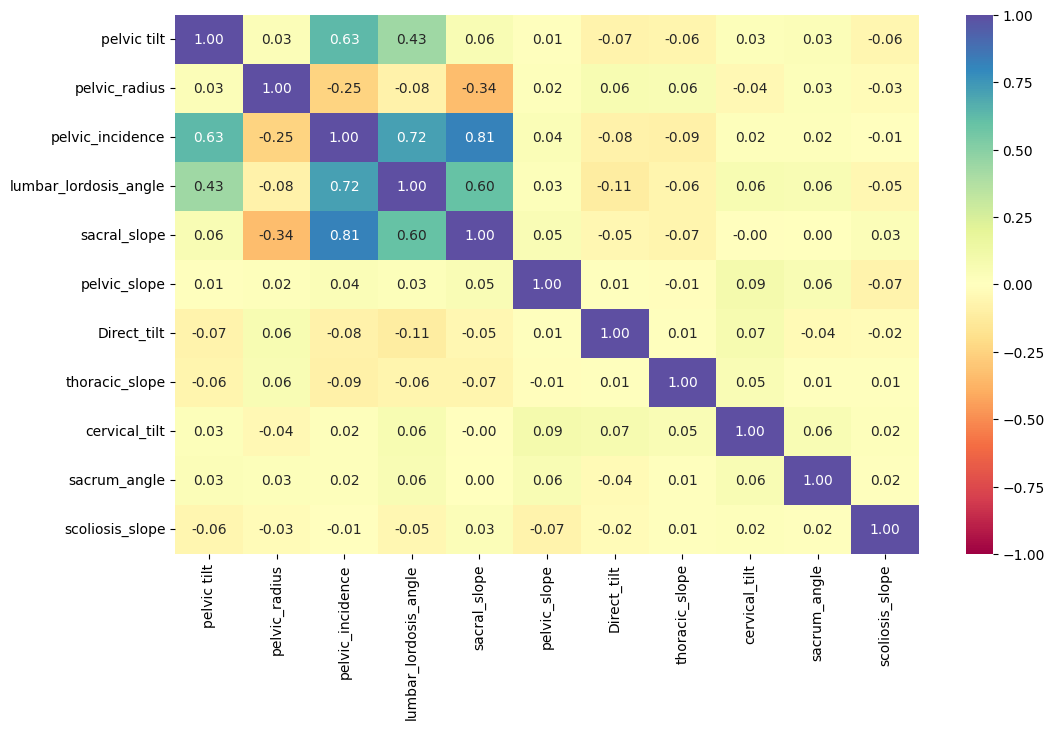

In [18]:
num_features = ['pelvic tilt', 'pelvic_radius', 'pelvic_incidence', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_slope', 'Direct_tilt', 'thoracic_slope', 'cervical_tilt', 'sacrum_angle', 'scoliosis_slope']
# defining the size of the plot
plt.figure(figsize=(12, 7))

# plotting the heatmap for correlation
sns.heatmap(backpaindf[num_features].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral");

In [60]:
X = backpaindf.drop(["Status"], axis=1)
y = backpaindf["Status"]
# creating dummy variables
X = pd.get_dummies(X, columns=X.select_dtypes(include=["object", "category"]).columns.tolist(), drop_first=True)

# specifying the datatype of the independent variables data frame
X = X.astype(float)

X.head()

,pelvic_incidence,pelvic tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,pelvic_slope,Direct_tilt,thoracic_slope,cervical_tilt,sacrum_angle,scoliosis_slope
0,63.02782,22.55259,39.60912,40.47523,98.67292,-0.25440,0.74450,12.56610,14.53860,15.30468,-28.65850,43.51230
1,39.05695,10.06099,25.01538,28.99596,114.40543,4.56426,0.41519,12.88740,17.53230,16.78486,-25.53061,16.11020
2,68.83202,22.21848,50.09219,46.61354,105.98514,-3.53032,0.47489,26.83430,17.48610,16.65897,-29.03189,19.22210
3,69.29701,24.65288,44.31124,44.64413,101.86850,11.21152,0.36935,23.56030,12.70740,11.42447,-30.47025,18.83290
4,49.71286,9.65207,28.31741,40.06078,108.16872,7.91850,0.54336,35.49400,15.95460,8.87237,-16.37838,24.91710


In [61]:
# label encoding the response variable
y = y.map({'Normal': 1, 'Abnormal': 0})
y.head()

,Status
0,0
1,0
2,0
3,0
4,0


In [62]:
trainX, testX, trainY, testY=train_test_split(X,y, test_size = 0.3)

In [63]:
print("Shape of training set:", trainX.shape)
print("Shape of test set:", testX.shape, '\n')
print("Percentage of classes in training set:")
print(100*trainY.value_counts(normalize=True), '\n')
print("Percentage of classes in test set:")
print(100*testY.value_counts(normalize=True))

Shape of training set: (217, 12)
Shape of test set: (93, 12) 

Percentage of classes in training set:
Status
0   69.12442
1   30.87558
Name: proportion, dtype: float64 

Percentage of classes in test set:
Status
0   64.51613
1   35.48387
Name: proportion, dtype: float64


In [64]:
# creating an instance of the decision tree model
dtree1 = DecisionTreeClassifier(random_state=42)    # random_state sets a seed value and enables reproducibility

# fitting the model to the training data
dtree1.fit(trainX, trainY)

DecisionTreeClassifier(random_state=42)

In [65]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [66]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def plot_confusion_matrix(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictors)

    # Compute the confusion matrix comparing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    # Create labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)    # reshaping to a matrix

    # Set the figure size for the plot
    plt.figure(figsize=(6, 4))

    # Plot the confusion matrix as a heatmap with the labels
    sns.heatmap(cm, annot=labels, fmt="")

    # Add a label to the y-axis
    plt.ylabel("True label")

    # Add a label to the x-axis
    plt.xlabel("Predicted label")

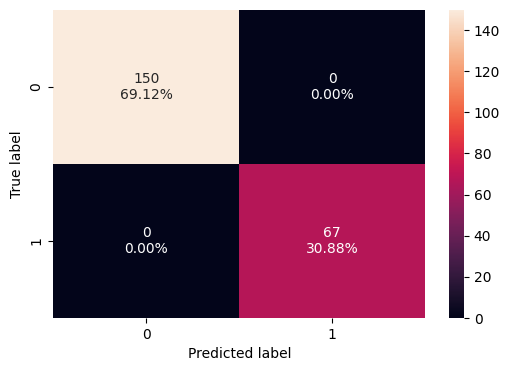

In [67]:
plot_confusion_matrix(dtree1, trainX, trainY)

In [68]:
dtree1_train_perf = model_performance_classification(
    dtree1, trainX, trainY
)
dtree1_train_perf

,Accuracy,Recall,Precision,F1
0,1.00000,1.00000,1.00000,1.00000


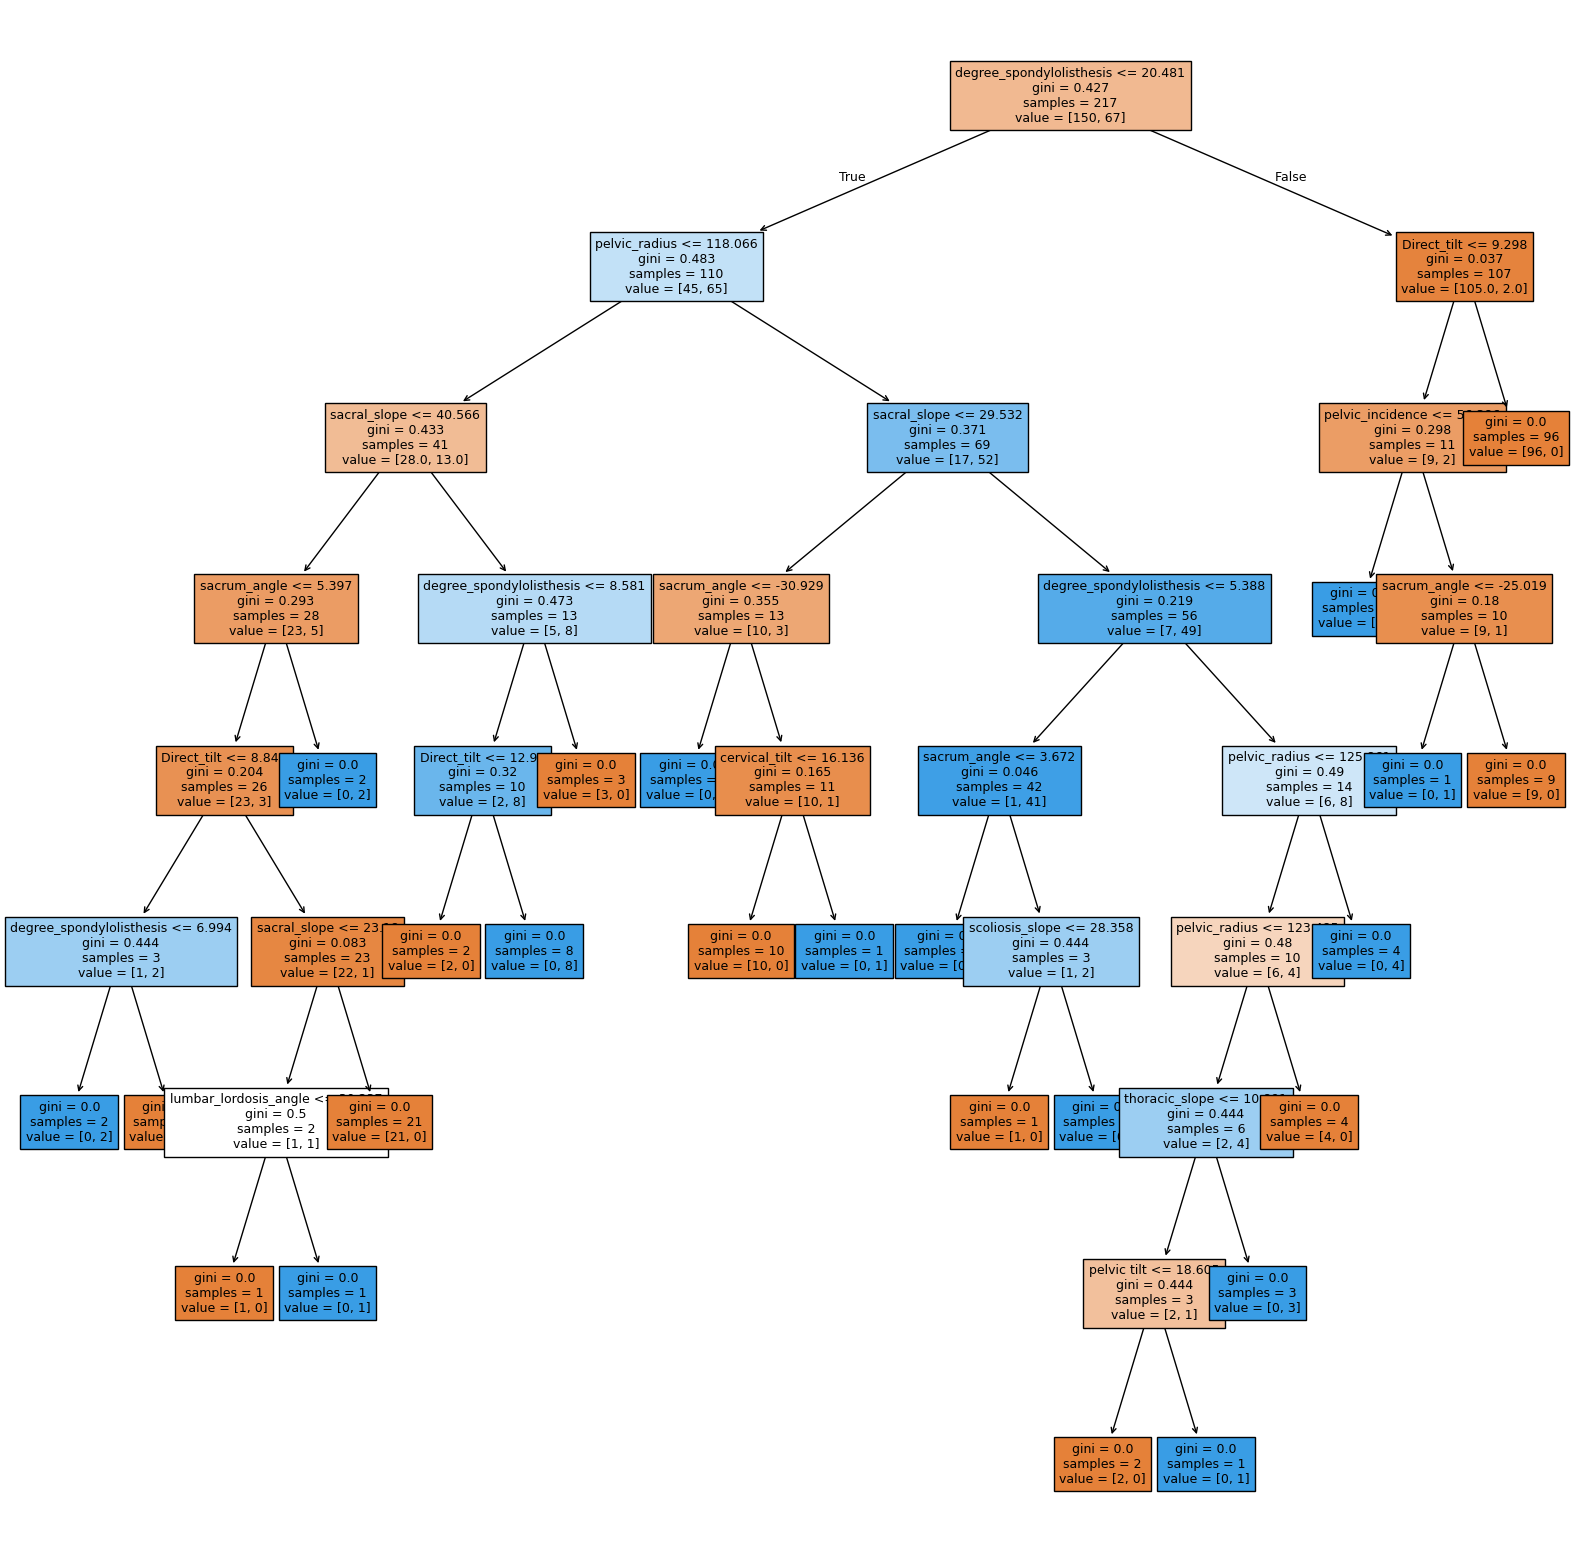

In [70]:
# list of feature names in X_train
feature_names = list(trainX.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree1,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

In [73]:
# define the parameters of the tree to iterate over
max_depth_values = np.arange(1, 8, 2)
max_leaf_nodes_values = np.arange(10, 51, 10)
min_samples_split_values = np.arange(10, 51, 10)

# initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')

# iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                random_state=42
            )

            # fit the model to the training data
            estimator.fit(trainX, trainY)

            # make predictions on the training and test sets
            y_train_pred = estimator.predict(trainX)
            y_test_pred = estimator.predict(testX)

            # calculate F1 scores for training and test sets
            train_f1_score = f1_score(trainY, y_train_pred)
            test_f1_score = f1_score(testY, y_test_pred)

            # calculate the absolute difference between training and test F1 scores
            score_diff = abs(train_f1_score - test_f1_score)

            # update the best estimator and best score if the current one has a smaller score difference
            if score_diff < best_score_diff:
                best_score_diff = score_diff
                best_estimator = estimator

In [74]:
# creating an instance of the best model
dtree2 = best_estimator

# fitting the best model to the training data
dtree2.fit(trainX, trainY)

DecisionTreeClassifier(max_depth=1, max_leaf_nodes=10, min_samples_split=10,
                       random_state=42)

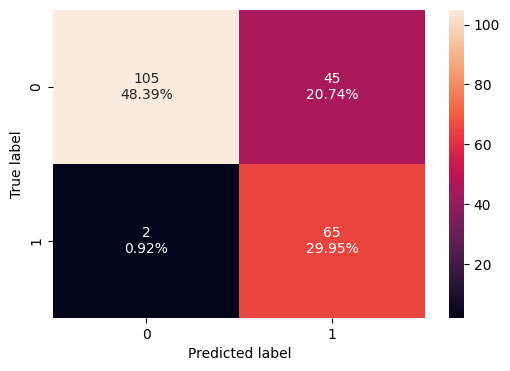

In [75]:
plot_confusion_matrix(dtree2, trainX, trainY)

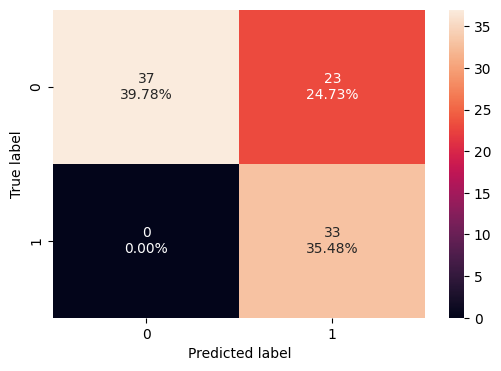

In [76]:
plot_confusion_matrix(dtree2, testX, testY)

In [78]:
dtree2_train_perf = model_performance_classification(
    dtree2, trainX, trainY
)
dtree2_train_perf

,Accuracy,Recall,Precision,F1
0,0.78341,0.97015,0.59091,0.73446


In [79]:
dtree2_train_perf = model_performance_classification(
    dtree2, testX, testY
)
dtree2_train_perf

,Accuracy,Recall,Precision,F1
0,0.75269,1.00000,0.58929,0.74157


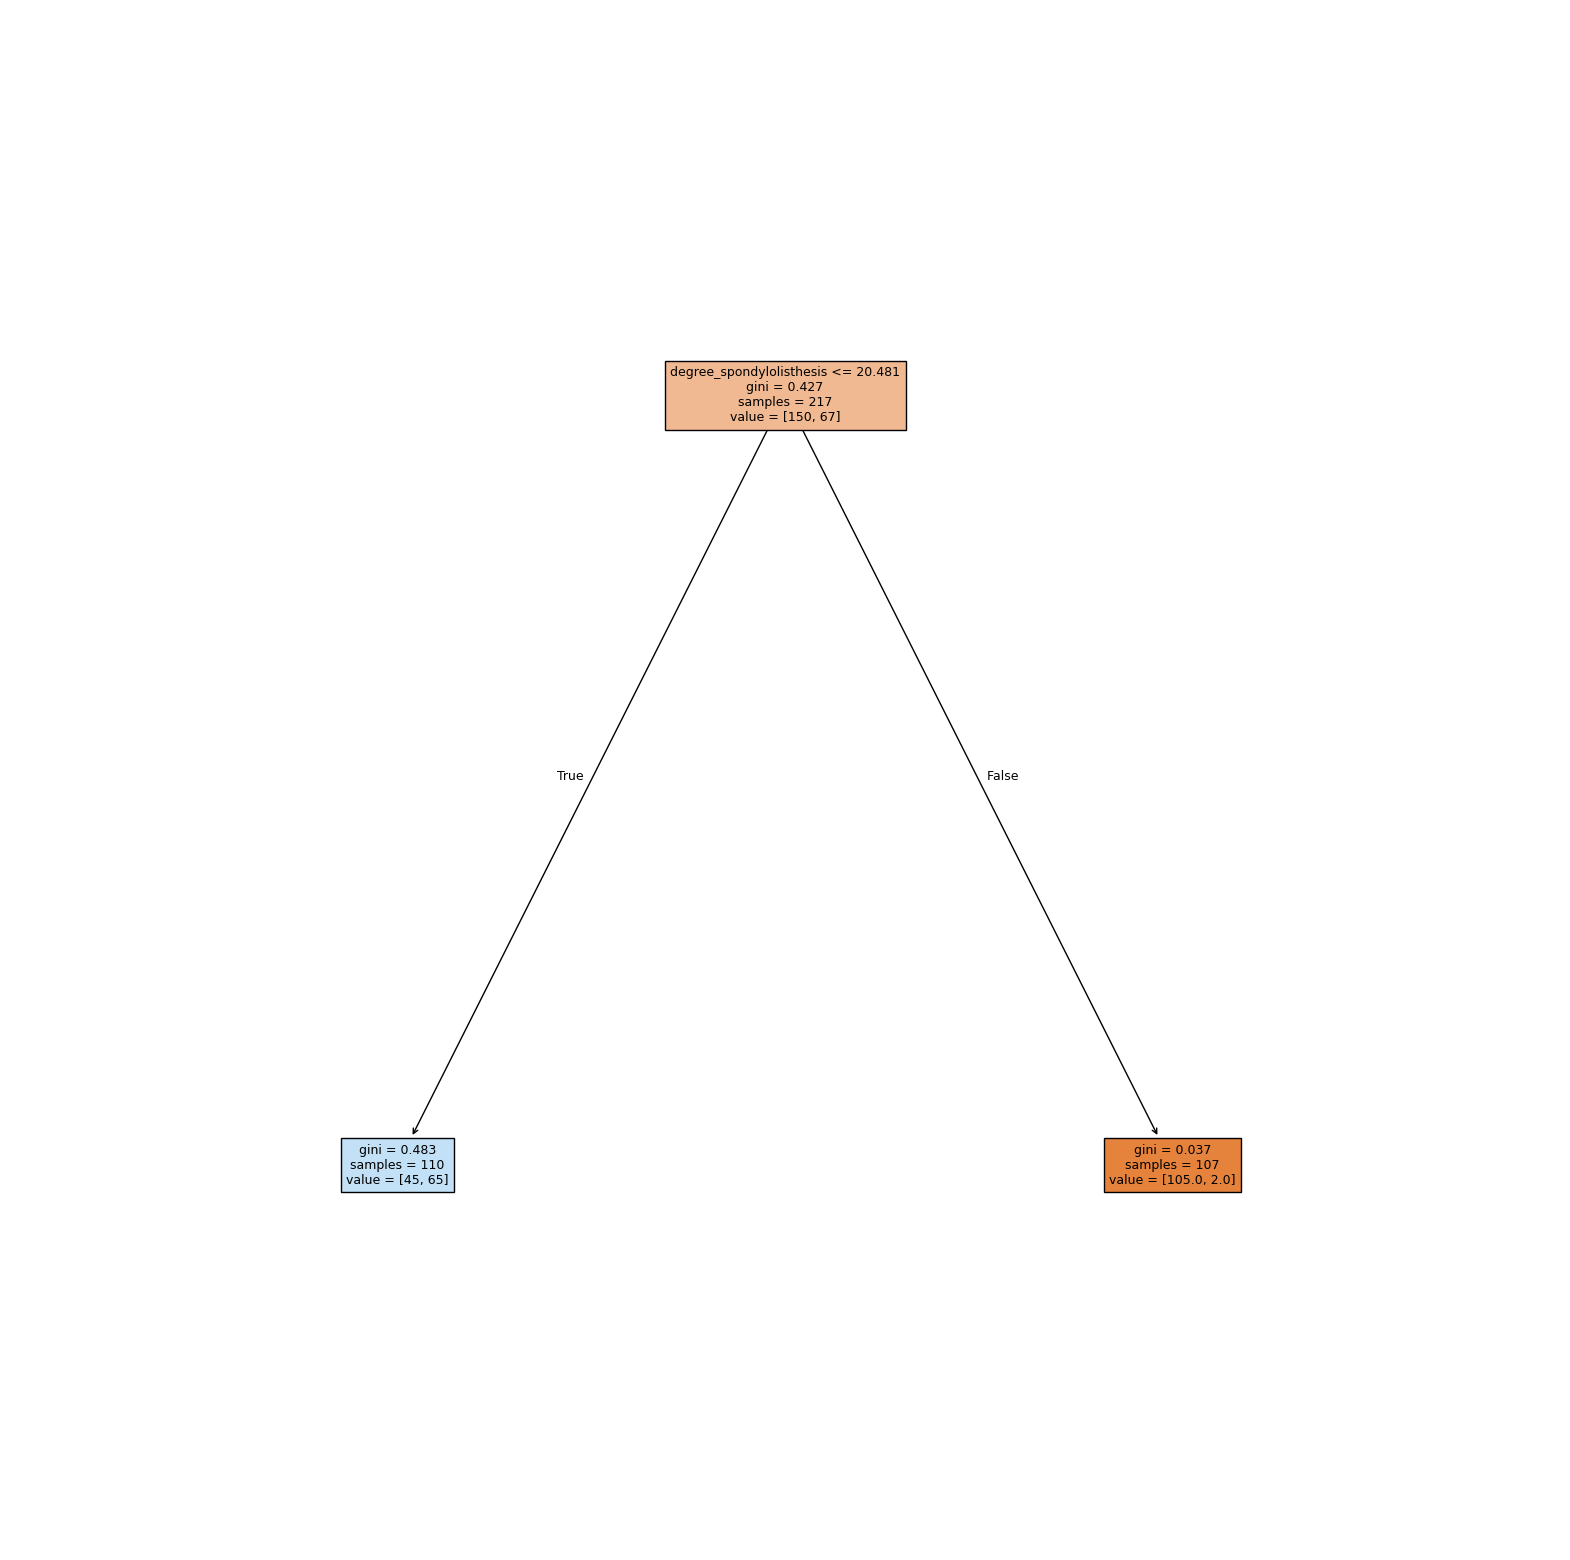

In [80]:
# list of feature names in X_train
feature_names = list(trainX.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree2,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()